In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from pyproj import CRS
import os

In [ ]:
# Cell 1: Define the ChicagoAnalysis class
class ChicagoAnalysis:
    """
    A class for analyzing Chicago metropolitan area spatial data.
    Focuses on common GIS operations using real Chicago datasets.
    """

    def __init__(self):
        """
        Initialize the ChicagoAnalysis class with API endpoints URLs for data:

        """
        self.data_urls = {
            'communities': 'https://data.cityofchicago.org/resource/igwz-8jzy.geojson',
            'parks': 'https://data.cityofchicago.org/resource/ejsh-fztr.geojson',
            'crimes': 'https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$query=SELECT%0A%20%20%60id%60%2C%0A%20%20%60case_number%60%2C%0A%20%20%60date%60%2C%0A%20%20%60block%60%2C%0A%20%20%60iucr%60%2C%0A%20%20%60primary_type%60%2C%0A%20%20%60description%60%2C%0A%20%20%60location_description%60%2C%0A%20%20%60arrest%60%2C%0A%20%20%60domestic%60%2C%0A%20%20%60beat%60%2C%0A%20%20%60district%60%2C%0A%20%20%60ward%60%2C%0A%20%20%60community_area%60%2C%0A%20%20%60fbi_code%60%2C%0A%20%20%60x_coordinate%60%2C%0A%20%20%60y_coordinate%60%2C%0A%20%20%60year%60%2C%0A%20%20%60updated_on%60%2C%0A%20%20%60latitude%60%2C%0A%20%20%60longitude%60%2C%0A%20%20%60location%60%0AWHERE%0A%20%20%60date%60%0A%20%20%20%20BETWEEN%20%222020-01-01T00%3A00%3A00%22%20%3A%3A%20floating_timestamp%0A%20%20%20%20AND%20%222024-12-31T23%3A45%3A00%22%20%3A%3A%20floating_timestamp%0AORDER%20BY%20%60date%60%20DESC%20NULL%20FIRST'
        }

        # declare these data attributes the class is designed to work with will exist for later use later
        self.communities = None
        self.parks = None
        self.crimes = None

In [ ]:
chicago = ChicagoAnalysis()

In [ ]:
type(chicago.data_urls)

In [ ]:
print(chicago.communities)

In [ ]:
print(chicago.schools)

In [ ]:
# Cell 2: create a method to load community data
def load_communities(self):
    """Load Chicago Community Areas boundary data"""
    print("Loading Chicago Community Areas...")
    # install /Applications/Python\ 3.12/Install\ Certificates.command in MacOS to access HTTPS endpoints
    self.communities = gpd.read_file(self.data_urls['communities'])  # use read_file() for reading spatial data formats such a .geojson, .shp, .gpkg
    self.communities = self.communities.to_crs(epsg='3435') # Transform to different CRS
    print(f"Loaded {len(self.communities)} community areas")
    return self.communities

# This line adds the method to the ChicagoAnalysis class
ChicagoAnalysis.load_communities = load_communities

In [ ]:
chicago.load_communities()

In [ ]:
# Cell 3: create a method to load Chicago park data
def load_parks(self):
    """Load Chicago Park Areas boundary data"""
    print("Loading Chicago Park Areas...")
    self.parks = gpd.read_file(self.data_urls['parks'])  #
    self.parks = self.parks.to_crs(epsg='3435') # project the data
    print(f"Loaded {len(self.parks)} park areas")
    return self.parks

# This line adds the method to the ChicagoAnalysis class
ChicagoAnalysis.load_parks = load_parks

In [ ]:
chicago.load_parks()

In [ ]:
chicago.parks.shape

# list of basic description functions for a Geodataframe
# chicago.parks.head()        # View first 5 rows
# chicago.parks.tail()        # View last 5 rows
# chicago.parks.info()        # Summary of DataFrame including data types and null values
# chicago.parks.shape         # Returns (rows, columns)
# chicago.parks.columns       # List column names
# chicago.parks.dtypes        # Data types of each column
# chicago.parks.crs           # Shows Coordinate Reference System

In [ ]:
chicago.parks.isnull().sum()

# list of statistical functions for a Geodataframe
# chicago.parks..describe()            # Statistical summary of numeric columns
# chicago.parks.['park_class'].value_counts()  # Frequency count of values in a column
# chicago.parks.groupby('park_class').sum()   # Group by a column and sum values
# chicago.parks.isnull().sum()       # Count null values in each column

In [ ]:
chicago.parks.total_bounds
# gdf.geom_type          # Type of geometry for each row
# gdf.geometry.bounds    # Returns DataFrame with minx, miny, maxx, maxy for each geometry
# gdf.total_bounds      # Returns (minx, miny, maxx, maxy) for entire GeoDataFrame
# gdf.geometry.area     # Calculate area of each geometry
# gdf.geometry.length   # Calculate perimeter/length of each geometry
# gdf.geometry.centroid # Get centroids of each geometry
# gdf.is_valid        # Check if geometries are valid
# gdf.is_empty        # Check if geometries are empty
# gdf.is_ring         # Check if geometries form a ring
# gdf.is_simple       # Check if geometries are simple
# gdf.geometry.type   # Get geometry type

In [ ]:
# Cell 4: create a method to load Chicago Crime Points (Date is 2024)
def load_crimes(self):
    """Load Chicago Crime incident data"""
    print("Loading Chicago Crime date...")

    # method 1: HTTP CSV endpoints (1000 rows limits)
    # use pd.read_csv() and gpd_GeoDataframe to create a geodataframe from a CSV endpoint URL
    # self.crimes = pd.read_csv(self.data_urls['crimes'])
    # method 2: local CSV file
    self.crimes = pd.read_csv('datasets/chicago_crime_2024.csv')
    self.crimes = gpd.GeoDataFrame(self.crimes,geometry=gpd.points_from_xy(self.crimes.Longitude, self.crimes.Latitude),crs="EPSG:4326")
    self.crimes = self.crimes.to_crs(epsg='3435') # project the data
    print(f"Loaded {len(self.crimes)} crime points")
    return self.crimes

ChicagoAnalysis.load_crimes = load_crimes

In [ ]:
chicago.load_crimes()

In [ ]:
chicago.crimes.shape

In [ ]:
# Cell 5: Analyze Parks by Communities
def analyze_parks(self):
    """Analyze parks distribution across community areas"""
    if self.communities is None or self.parks is None:
        raise ValueError("Try loading community areas or/and parks data successfully first.")

    # Checks which community area geometry intersects with it using gpd.sjoin()
    parks_by_area = gpd.sjoin(self.parks, self.communities)

    # Calculate parks statistics by community area
    parks_stats = parks_by_area.groupby('community').\
        agg({'geometry': 'count', 'park_class': 'nunique'}).\
        rename(columns={'geometry': 'num_parks', 'park_class': 'park_types'})

    return parks_stats

ChicagoAnalysis.analyze_parks = analyze_parks

In [ ]:
# parks: 617; communities: 77

# Calculate park class distribution by community area
parks_within_communities = gpd.sjoin(chicago.parks, chicago.communities)

# Using pivot_table
park_counts_by_class = parks_within_communities.pivot_table(
    index='community',        # each row will be a community
    columns='park_class',     # each unique park_class becomes a column
    values='geometry',        # count these values
    aggfunc='count',         # use counting as the aggregation
    fill_value=0             # fill missing values with 0
).rename_axis(None, axis=1)  # This removes the column index name

# Add total parks column
park_counts_by_class['total_parks'] = park_counts_by_class.sum(axis=1)

# If you want community as a column instead of index
park_counts_by_class = park_counts_by_class.reset_index()

In [ ]:
park_counts_by_class.columns

In [ ]:
park_counts_by_class

In [ ]:
chicago.communities

In [ ]:
chicago.communities = chicago.communities[['community','geometry']]
chicago.communities

In [ ]:
# merge the df and gdf using merging
chicago_communities_parks_stat = chicago.communities.merge(
    park_counts_by_class,
    how='left', # keep all rows of communities even if no parks
    left_on='community',
    right_on='community',
).fillna(0)             # fill any NaN values with 0
chicago_communities_parks_stat

In [ ]:
# Exercise 2: Create a crime density map

In [159]:
# Add this import at the top
import cartopy.crs as ccrs
from cartopy.io.img_tiles import OSM
import osmnx as ox
import seaborn as sns
from scipy.stats import gaussian_kde

In [160]:
chicago.crimes['Primary Type'].unique()

array(['BATTERY', 'CRIMINAL DAMAGE', 'MOTOR VEHICLE THEFT',
       'OTHER OFFENSE', 'WEAPONS VIOLATION', 'ASSAULT', 'THEFT',
       'CRIMINAL SEXUAL ASSAULT', 'ROBBERY', 'DECEPTIVE PRACTICE',
       'CONCEALED CARRY LICENSE VIOLATION', 'BURGLARY', 'NARCOTICS',
       'LIQUOR LAW VIOLATION', 'CRIMINAL TRESPASS',
       'OFFENSE INVOLVING CHILDREN', 'KIDNAPPING', 'HOMICIDE', 'ARSON',
       'SEX OFFENSE', 'INTERFERENCE WITH PUBLIC OFFICER', 'STALKING',
       'PUBLIC PEACE VIOLATION', 'INTIMIDATION', 'GAMBLING',
       'PROSTITUTION', 'PUBLIC INDECENCY', 'OBSCENITY',
       'HUMAN TRAFFICKING', 'NON-CRIMINAL', 'OTHER NARCOTIC VIOLATION'],
      dtype=object)

## Create density map

In [174]:
chicago.communities['community']

0             DOUGLAS
1             OAKLAND
2         FULLER PARK
3     GRAND BOULEVARD
4             KENWOOD
           ...       
72    MOUNT GREENWOOD
73        MORGAN PARK
74              OHARE
75          EDGEWATER
76        EDISON PARK
Name: community, Length: 77, dtype: object

In [187]:
# First get the LOOP community area geometry and create a buffer
loop_area = chicago.communities[chicago.communities['community'] == 'LOOP'].geometry.iloc[0]
loop_buffer = loop_area.buffer(10000)  # 5280 feet = 1 mile

In [188]:
type(loop_buffer)

shapely.geometry.polygon.Polygon

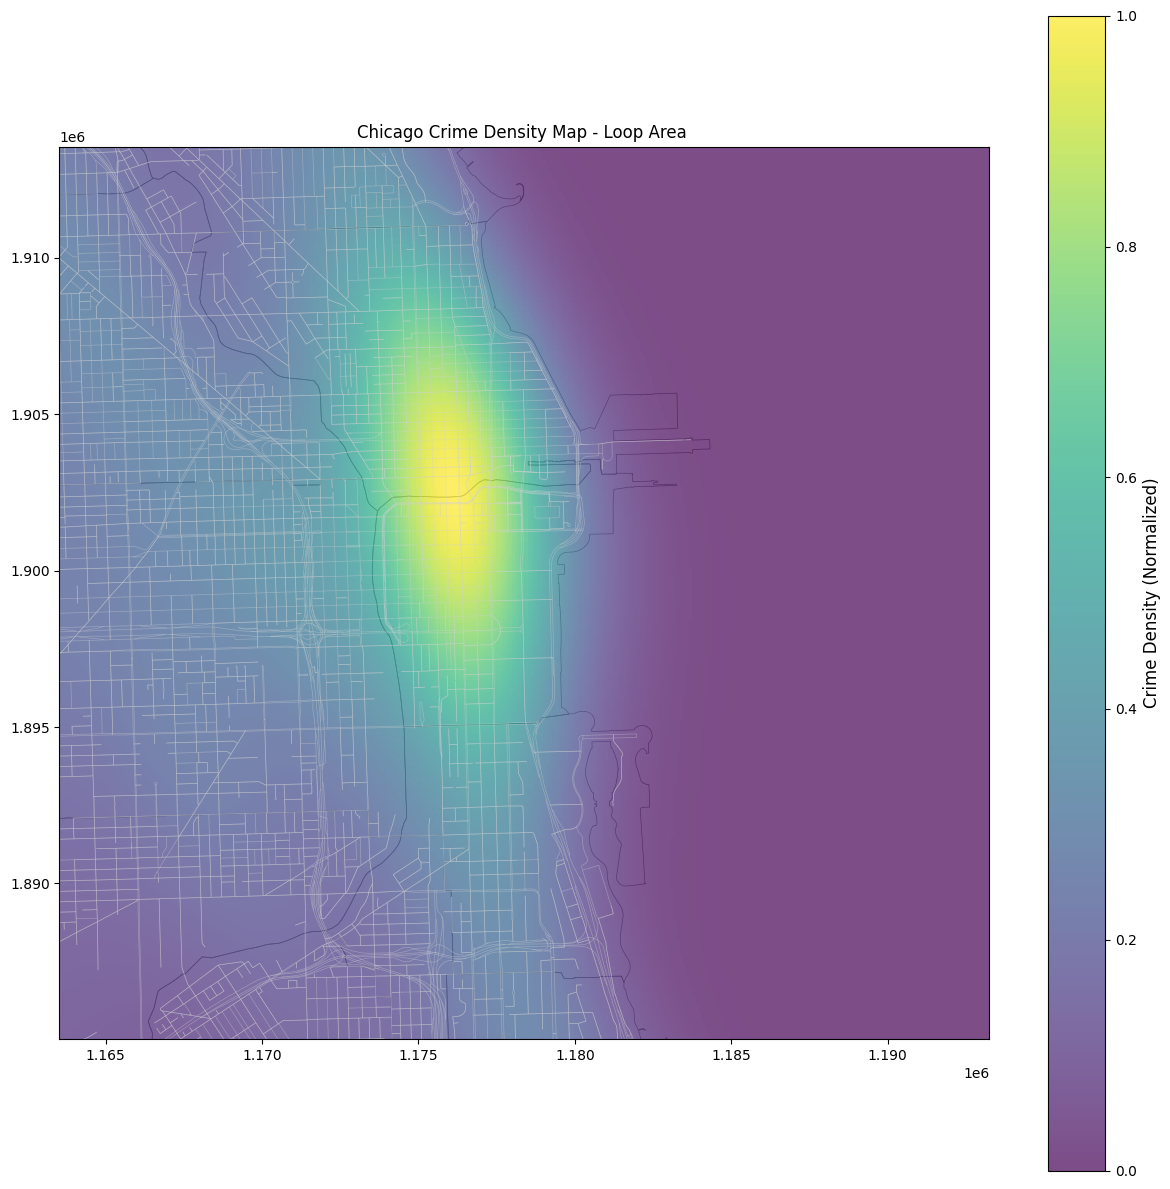

In [194]:
# Get the bounds of the buffer
bounds = loop_buffer.bounds  # Returns (minx, miny, maxx, maxy) = (1168244.7133099458, 1889734.990553004, 1188536.8361972792, 1908838.7701331528)

# Create figure with white background
fig, ax = plt.subplots(figsize=(15, 15), facecolor='white')
ax.set_facecolor('white')

# Set plot limits to buffer extent
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])

# Create base map layers
roads = ox.graph_from_place('Chicago, Illinois, USA', network_type='drive')
roads_gdf = ox.graph_to_gdfs(roads, nodes=False)
roads_gdf = roads_gdf.to_crs(chicago.communities.crs)

# Plot base layers
chicago.communities.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.5)
roads_gdf.plot(ax=ax, color='lightgray', alpha=0.4, linewidth=0.5)

# Plot density grids
# Step1: Clean and prepare data for density estimation
x = chicago.crimes.geometry.x
y = chicago.crimes.geometry.y
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# Step2: Calculate the kernel density
xy = np.vstack([x, y])
kde = gaussian_kde(xy, bw_method='scott')  # Adjust bandwidth method

# Step3: Create a finer grid for smooth visualization
xi = np.linspace(bounds[0], bounds[2], 300)  # Increase resolution
yi = np.linspace(bounds[1], bounds[3], 300)
xi, yi = np.meshgrid(xi, yi)

# Step4: Evaluate the density on the grid
positions = np.vstack([xi.ravel(), yi.ravel()])
zi = kde(positions)
zi = zi.reshape(xi.shape)

# Step5: Normalize the density values
zi = (zi - zi.min()) / (zi.max() - zi.min())

# Step6: Plot density map with adjusted parameters
density = ax.pcolormesh(xi, yi, zi,
                       cmap='viridis',  # Changed to viridis for better contrast
                       alpha=0.7,
                       shading='auto',
                       vmin=0,
                       vmax=zi.max()
                        )
# Step8(optional): Add colorbar with adjusted label
cbar = plt.colorbar(density, ax=ax)
cbar.set_label('Crime Density (Normalized)', size=12)

# Display the plot
plt.title("Chicago Crime Density Map - Loop Area ")
plt.show()

In [196]:
# Print some statistics
print(f"Total crimes in buffer zone: {len(chicago.crimes)}")
print(f"Total crimes with valid coordinates: {len(x)}")

Total crimes in buffer zone: 256341
Total crimes with valid coordinates: 256201


## Plotting Locations for filtered crime incidents

In [199]:
import folium

In [225]:
# Filter Primary Type
crime_filtered = chicago.crimes[chicago.crimes['Primary Type'] == 'HOMICIDE']

# Calculate centroid while data is still in projected CRS (3435)
communities_center_point = chicago.communities.dissolve().centroid

# Convert the centroid point to 4326
communities_center_point_4326 = communities_center_point.to_crs(epsg='4326')

# Get center coordinates
# print(type(communities_center_point_4326.y)) # pandas.core.series.Series
# print(type(communities_center_point_4326))  # geopandas.geoseries.GeoSeries
center_lat = float(communities_center_point_4326.y.iloc[0])  # use .iloc[0] to get a single value from a Series
center_lon = float(communities_center_point_4326.x.iloc[0])

# Convert other data to 4326 for mapping
crime_filtered_4326 = crime_filtered.to_crs(epsg='4326')
communities_4326 = chicago.communities.to_crs(epsg='4326')

m = folium.Map(location=[41.837102432597405, -87.6857827922004],
               zoom_start=11,
               tiles='CartoDB positron')  # Light theme base map

# Add community boundaries
folium.GeoJson(
    communities_4326,
    style_function=lambda x: {
        'fillColor': 'none',
        'color': 'gray',
        'weight': 1,
        'opacity': 0.7
    }
).add_to(m)

# Add individual crime points
for idx, row in crime_filtered_4326.iterrows():
    if row.geometry and not row.geometry.is_empty:
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=3,  # Size of the circle
            color='red',  # Circle edge color
            fill=True,
            fillColor='red',  # Circle fill color
            fillOpacity=0.7,
            popup=f"Crime ID: {row.name}"  # You can customize this with other columns
        ).add_to(m)

# Display the map
display(m)

## Analysis of crime by communities

In [279]:
def analyze_crime_by_community(self):
    """Calculate crime statistics by community area"""
    if self.crimes is None or self.communities is None:
        raise ValueError("Please load crime and community areas data first")

    # Spatial join crimes with community areas
    crimes_in_communities = gpd.sjoin(self.crimes, self.communities)

    # Calculate crime statistics
    self.crime_stats = crimes_in_communities.groupby('community').agg({
        'Primary Type': ['count', 'nunique'],
        'Arrest': 'sum'
    })

    self.crime_stats.columns = ['total_crimes', 'crime_types', 'total_arrests']
    return self.crime_stats

ChicagoAnalysis.analyze_crime_by_community = analyze_crime_by_community

In [280]:
chicago.analyze_crime_by_community()

,total_crimes,crime_types,total_arrests
community,,,
ALBANY PARK,2448,25,290
ARCHER HEIGHTS,1100,21,133
ARMOUR SQUARE,1091,24,139
ASHBURN,2368,22,138
AUBURN GRESHAM,6569,27,796
...,...,...,...
WEST LAWN,1921,20,206
WEST PULLMAN,3663,25,497
WEST RIDGE,3603,25,324


In [245]:
crimes_in_communities = gpd.sjoin(chicago.crimes, chicago.communities)
community_crime_stats = crimes_in_communities.groupby('community').agg({
    'ID': 'count',  # Total number of crimes
    'Primary Type': lambda x: x.mode().iloc[0],  # Most frequent crime type
    'Date': ['min', 'max'],  # First and last crime dates
    'Arrest': 'sum',  # Number of arrests
    'Domestic': 'sum',  # Number of domestic incidents
    'Ward': 'first',  # Ward number
    'District': 'first'  # Police district
}).round(2)
community_crime_stats

ID Primary Type                    Date  \
               count     <lambda>                     min   
community                                                   
ALBANY PARK     2448        THEFT  01/01/2024 01:00:00 PM   
ARCHER HEIGHTS  1100        THEFT  01/01/2024 02:40:00 AM   
ARMOUR SQUARE   1091        THEFT  01/01/2024 03:00:00 AM   
ASHBURN         2368        THEFT  01/01/2024 01:00:00 PM   
AUBURN GRESHAM  6569      BATTERY  01/01/2024 01:00:00 AM   
...              ...          ...                     ...   
WEST LAWN       1921        THEFT  01/01/2024 04:45:00 AM   
WEST PULLMAN    3663      BATTERY  01/01/2024 02:11:00 AM   
WEST RIDGE      3603        THEFT  01/01/2024 01:00:00 AM   
WEST TOWN       7938        THEFT  01/01/2024 01:00:00 PM   
WOODLAWN        3952      BATTERY  01/01/2024 01:38:00 AM   

                                       Arrest Domestic  Ward District  
                                   max    sum      sum first    first  
community                                                              
ALBANY PARK     12/31/2024 12:00:00 AM    290      431    39       17  
ARCHER HEIGHTS  12/31/2024 12:00:00 PM    133      135    14        8  
ARMOUR SQUARE   12/31/2024 12:22:00 PM    139      130    11        9  
ASHBURN         12/31/2024 05:00:00 AM    138      470    18        8  
AUBURN GRESHAM  12/31/2024 12:00:00 PM    796     1973    17        6  
...                                ...    ...      ...   ...      ...  
WEST LAWN       12/31/2024 05:02:00 AM    206      323    23        8  
WEST PULLMAN    12/31/2024 12:00:00 AM    497      957     9        5  
WEST RIDGE      12/31/2024 10:21:00 AM    324      553    40       24  
WEST TOWN       12/31/2024 11:42:00 PM    555      613    36       12  
WOODLAWN        12/31/2024 12:00:00 AM    489      944    20        3  

[77 rows x 8 columns]

## Create Choropleth Map

In [256]:
import contextily as ctx

In [296]:
def create_choropleth(self, column, title):
    """
    Create a choropleth map of Chicago community areas

    Parameters:
    -----------
    column : str
        Column name to use for choropleth coloring
    title : str
        Map title
    legend_label : str
        Label for the legend
    """
    # Create figure
    fig, ax = plt.subplots(figsize=(15, 15))

    # Plot choropleth using GeoDataFrame's plot method

    communities_crime_stats = self.communities.merge(
    self.crime_stats,
    how='left', # keep all rows of communities even if no parks
    left_on='community',
    right_on='community',
    ).fillna(0)             # fill any NaN values with 0

    communities_crime_stats.plot(
        column=column,
        ax=ax,
        cmap='YlOrRd'
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Customize map
    ax.set_title(title)  # Using ax.set_title is more reliable than plt.title
    ax.set_axis_off()    # Using ax.set_axis_off is more reliable than plt.axis('off')

    return fig, ax

# Add the method to the class
ChicagoAnalysis.create_choropleth = create_choropleth

In [297]:
chicago.crime_stats

,total_crimes,crime_types,total_arrests
community,,,
ALBANY PARK,2448,25,290
ARCHER HEIGHTS,1100,21,133
ARMOUR SQUARE,1091,24,139
ASHBURN,2368,22,138
AUBURN GRESHAM,6569,27,796
...,...,...,...
WEST LAWN,1921,20,206
WEST PULLMAN,3663,25,497
WEST RIDGE,3603,25,324


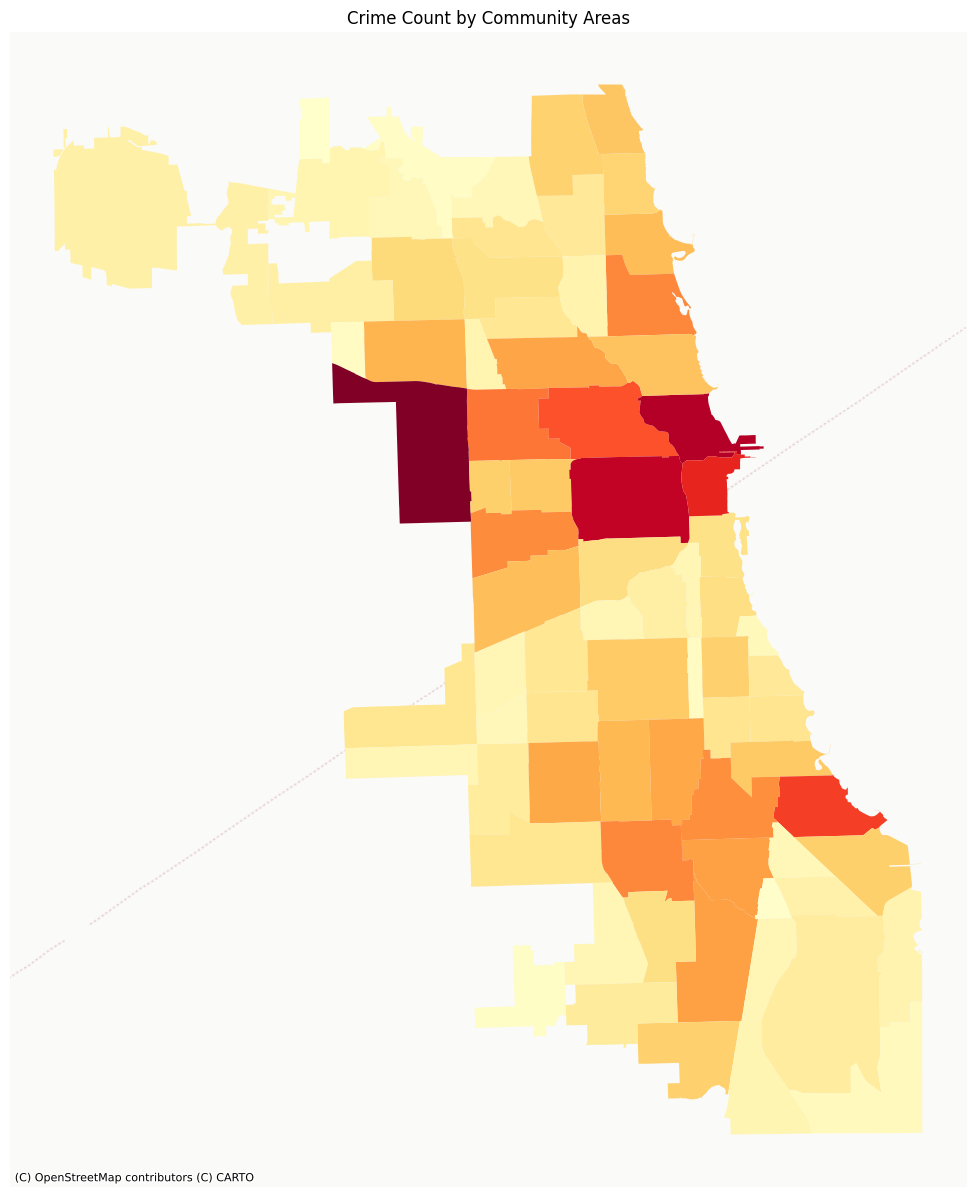

In [298]:
# Create choropleth of total crimes
chicago.create_choropleth(
    column='total_crimes',
    title='Crime Count by Community Areas'
)
plt.show()